# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [2]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [3]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.93MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.00MB/s]

Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [4]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [5]:
model = torch.nn.Linear(28*28, 10)

In [6]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[ 0.4888,  0.3365,  0.0401,  0.9499, -1.1713, -0.0521,  0.2951, -0.2672,
         -0.1918, -0.1270]], grad_fn=<AddmmBackward0>)

In [7]:
model(dataset_train[0][0].view(-1, 784))

tensor([[-0.0370,  0.2385, -0.1285,  0.0338, -0.5325,  0.1990, -0.1129, -0.0833,
         -0.0947,  0.0008]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [8]:
n_epochs = 10
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [9]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = x_train.view(-1, 28 * 28)
        labels = y_train

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = x_val.view(-1, 28 * 28)
            labels_val = y_val

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Epoch [1/10], Train Loss: 0.4035, Train Acc: 0.8864, Val Loss: 0.3374, Val Acc: 0.9037
Epoch [2/10], Train Loss: 0.3075, Train Acc: 0.9133, Val Loss: 0.3217, Val Acc: 0.9066
Epoch [3/10], Train Loss: 0.2924, Train Acc: 0.9171, Val Loss: 0.3145, Val Acc: 0.9103
Epoch [4/10], Train Loss: 0.2833, Train Acc: 0.9214, Val Loss: 0.3120, Val Acc: 0.9116
Epoch [5/10], Train Loss: 0.2774, Train Acc: 0.9220, Val Loss: 0.3046, Val Acc: 0.9113
Epoch [6/10], Train Loss: 0.2738, Train Acc: 0.9233, Val Loss: 0.3103, Val Acc: 0.9114
Epoch [7/10], Train Loss: 0.2690, Train Acc: 0.9247, Val Loss: 0.3052, Val Acc: 0.9141
Epoch [8/10], Train Loss: 0.2672, Train Acc: 0.9251, Val Loss: 0.2987, Val Acc: 0.9167
Epoch [9/10], Train Loss: 0.2644, Train Acc: 0.9259, Val Loss: 0.3070, Val Acc: 0.9136
Epoch [10/10], Train Loss: 0.2611, Train Acc: 0.9277, Val Loss: 0.3140, Val Acc: 0.9119


In [10]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

--- Treinamento Finalizado ---
Última perda de treinamento: 0.2611
Última acurácia de treinamento: 0.9277
Última perda de validação: 0.3140
Última acurácia de validação: 0.9119


### Visualizando a evolução da perda e acurácia

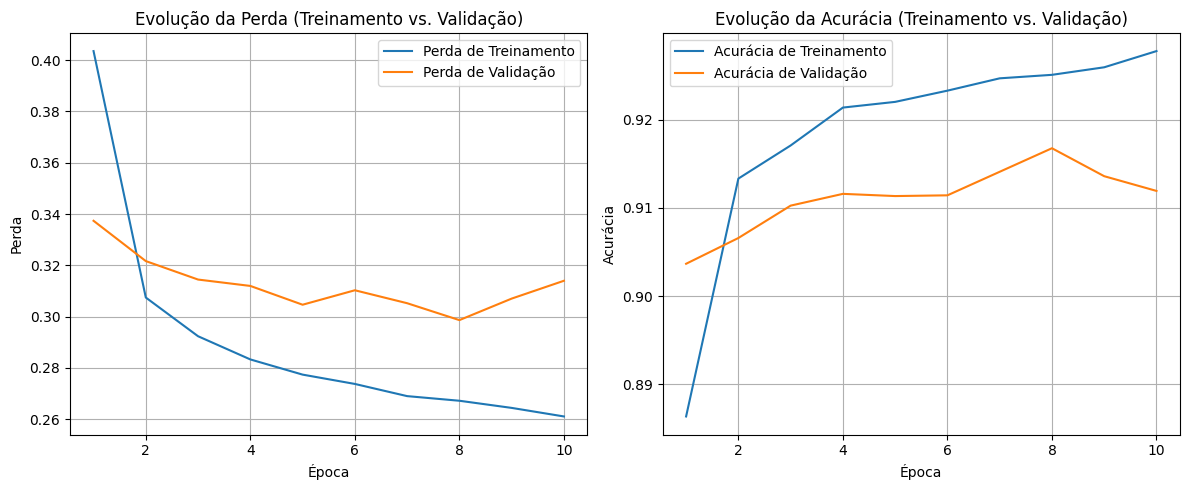

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?

R.: batch_size = 100

2. Em uma época, quantos mini-batches existem?

R.: 42000 valores de X_train. 42000/100 = 420 mini-batches

3. Qual é a definição de época?

R.: Quando o modelo calcula e ajusta os pesos baseado em todos os elementos do dataset (em todos os mini-batches)


## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600
2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

01

In [13]:
for epoch in range(n_epochs):

    for i, (b_x, b_y) in enumerate(loader_train):


        print(f'Época: {epoch+1}/{n_epochs}, batch: {i+1}')

Época: 1/10, batch: 1
Época: 1/10, batch: 2
Época: 1/10, batch: 3
Época: 1/10, batch: 4
Época: 1/10, batch: 5
Época: 1/10, batch: 6
Época: 1/10, batch: 7
Época: 1/10, batch: 8
Época: 1/10, batch: 9
Época: 1/10, batch: 10
Época: 1/10, batch: 11
Época: 1/10, batch: 12
Época: 1/10, batch: 13
Época: 1/10, batch: 14
Época: 1/10, batch: 15
Época: 1/10, batch: 16
Época: 1/10, batch: 17
Época: 1/10, batch: 18
Época: 1/10, batch: 19
Época: 1/10, batch: 20
Época: 1/10, batch: 21
Época: 1/10, batch: 22
Época: 1/10, batch: 23
Época: 1/10, batch: 24
Época: 1/10, batch: 25
Época: 1/10, batch: 26
Época: 1/10, batch: 27
Época: 1/10, batch: 28
Época: 1/10, batch: 29
Época: 1/10, batch: 30
Época: 1/10, batch: 31
Época: 1/10, batch: 32
Época: 1/10, batch: 33
Época: 1/10, batch: 34
Época: 1/10, batch: 35
Época: 1/10, batch: 36
Época: 1/10, batch: 37
Época: 1/10, batch: 38
Época: 1/10, batch: 39
Época: 1/10, batch: 40
Época: 1/10, batch: 41
Época: 1/10, batch: 42
Época: 1/10, batch: 43
Época: 1/10, batch: 

2


Iniciando treinamento com batch_size = 16...

Iniciando treinamento com batch_size = 64...

Iniciando treinamento com batch_size = 256...

Iniciando treinamento com batch_size = 1024...


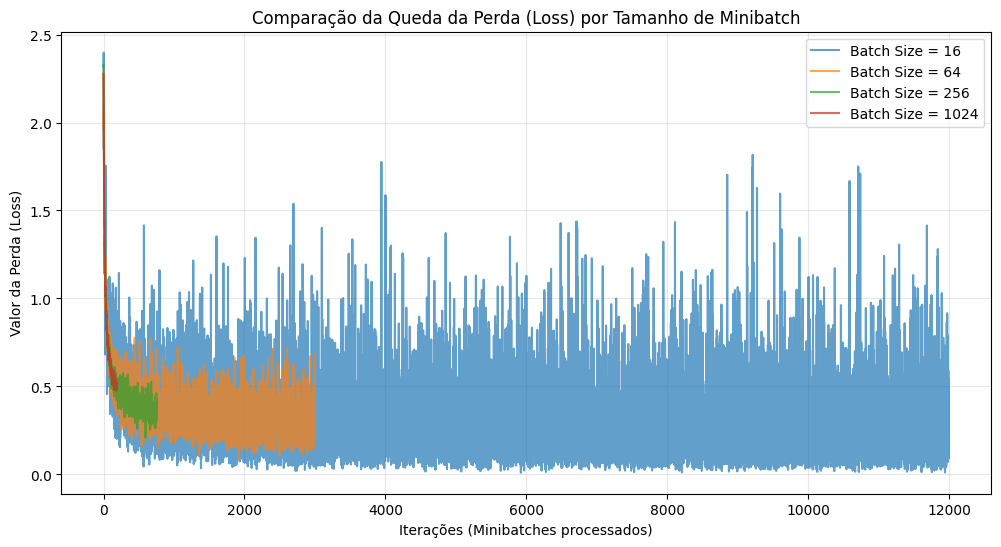

In [15]:
import matplotlib.pyplot as plt
import torch.nn as nn


tamanhos_batch = [16, 64, 256, 1024]
historico_perdas = {} # Dicionário para guardar as perdas de cada teste

epochs = 4 # Número de épocas pequeno para testar rápido

for bs in tamanhos_batch:
    print(f"\nIniciando treinamento com batch_size = {bs}...")

    # . Recria o DataLoader com o novo tamanho de batch

    train_loader = DataLoader(dataset_train, batch_size=bs, shuffle=True)

    #. Recria o modelo e o otimizador do zero para cada teste (para ser justo)
    model = torch.nn.Linear(28*28, 10)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    perdas_minibatch = []

    # . Laço de Treinamento
    for epoch in range(epochs):
        for b_x, b_y in train_loader:
            # Aplanar as imagens para o modelo Linear
            b_x_flattened = b_x.view(-1, 28 * 28)
            y_pred = model(b_x_flattened)
            loss = criterion(y_pred, b_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Guardamos o valor da perda para o gráfico
            perdas_minibatch.append(loss.item())

    # Salva no dicionário para plotar depois
    historico_perdas[bs] = perdas_minibatch

# --- PLOTANDO O GRÁFICO COMPARATIVO ---
plt.figure(figsize=(12, 6))

for bs, perdas in historico_perdas.items():
    plt.plot(perdas, label=f'Batch Size = {bs}', alpha=0.7)

plt.title('Comparação da Queda da Perda (Loss) por Tamanho de Minibatch')
plt.xlabel('Iterações (Minibatches processados)')
plt.ylabel('Valor da Perda (Loss)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusões sobre os experimentos deste notebook
